In [1]:
#Project Title: End-to-End Sales Forecasting & Demand Intelligence System 

In [2]:
#Task 1 — Data Loading, Merging & Deep Exploration 

In [3]:
#Import  Required Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns",None)#display all columns

In [4]:
#Load Dataset 
df = pd.read_csv("train.csv")
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
#Parse date Columns
#(It convert order date and ship date into date time format)

df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst = True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"],dayfirst = True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [7]:
# Extract time features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [8]:
# Create Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [9]:
#Check Missing Values
df.isnull().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

In [10]:
#percentage missing
missing = df.isnull().sum()/len(df)*100
missing.sort_values(ascending=False)

Postal Code      0.112245
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Row ID           0.000000
Country          0.000000
City             0.000000
State            0.000000
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
Year             0.000000
Month            0.000000
Month Name       0.000000
Week Number      0.000000
Day of Week      0.000000
Quarter          0.000000
Season           0.000000
dtype: float64

In [11]:
#Check Duplicate
duplicates = df.duplicated().sum()
print("Duplicate Rows:",duplicates)

Duplicate Rows: 0


In [12]:
#Remove Duplicate
df= df.drop_duplicates()

In [13]:
#Check DataTypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [14]:
#Aggregate Daily sales

#Daily Sales
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [15]:
#Weekly sales
weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [16]:
#Monthly sales
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()
monthly_sales.head(12)

C:\Users\aman\AppData\Local\Temp\ipykernel_7060\1020560960.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()


,Order Date,Sales
0,2015-01-31,14205.7070
1,2015-02-28,4519.8920
2,2015-03-31,55205.7970
3,2015-04-30,27906.8550
4,2015-05-31,23644.3030
5,2015-06-30,34322.9356
6,2015-07-31,33781.5430
7,2015-08-31,27117.5365
8,2015-09-30,81623.5268
9,2015-10-31,31453.3930


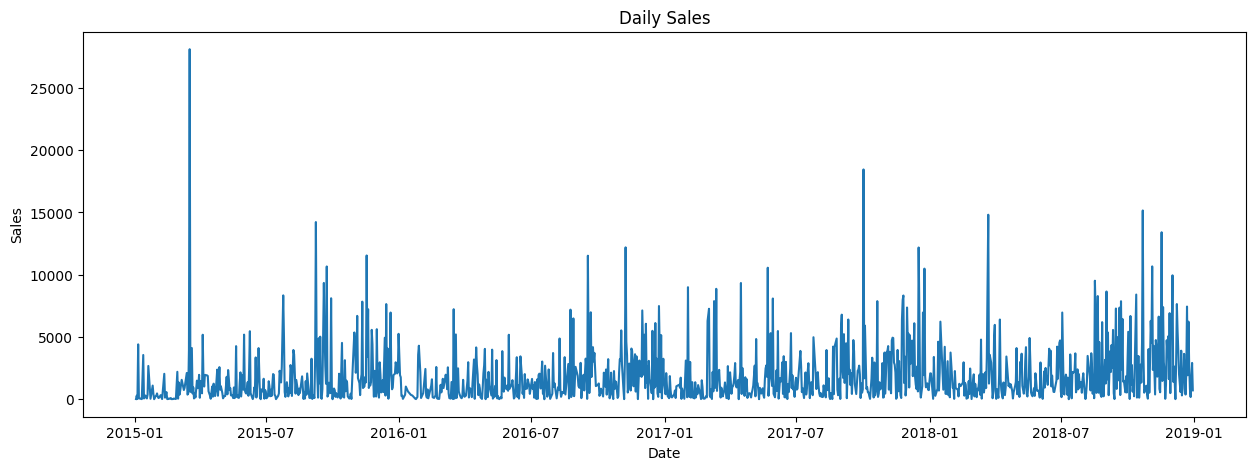

In [17]:
#Plot Daily Sales
plt.figure(figsize=(15,5))
plt.plot(daily_sales["Order Date"],daily_sales["Sales"])
plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.savefig("Daily_Sales.png")
plt.show()

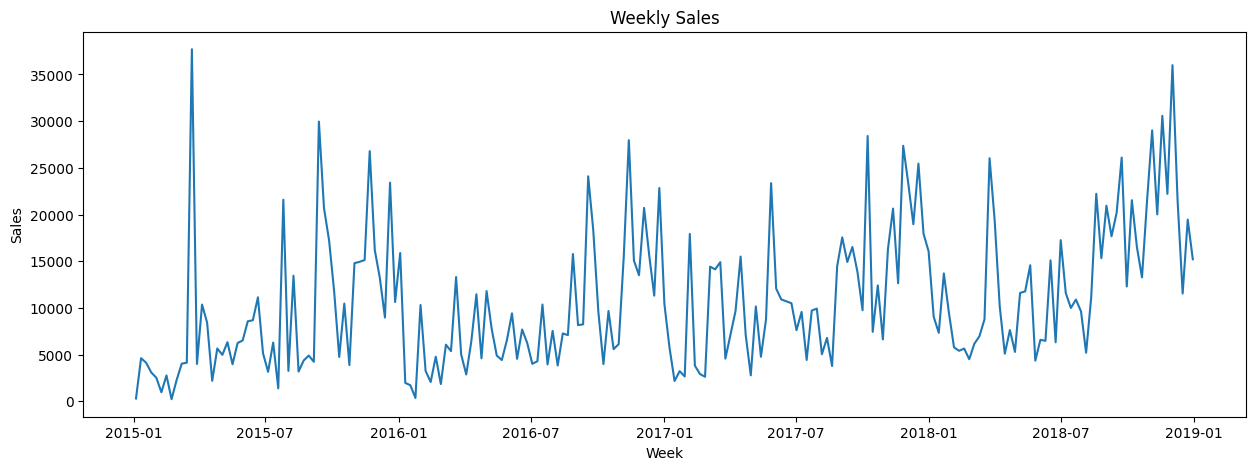

In [18]:
#Plot Weekly Sales
plt.figure(figsize=(15,5))
plt.plot(weekly_sales["Order Date"],weekly_sales["Sales"])
plt.title("Weekly Sales")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.savefig("Weekly_Sales.png")
plt.show()

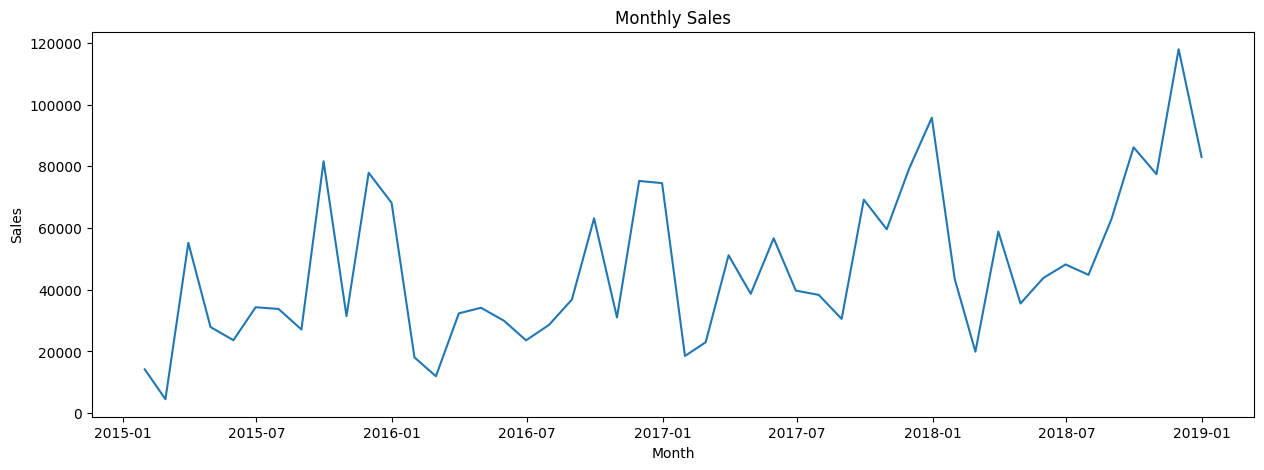

In [19]:
#Plot Monthly Sales
plt.figure(figsize=(15,5))
plt.plot(monthly_sales["Order Date"],monthly_sales["Sales"])
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig("Monthly_Sales.png")
plt.show()

In [20]:
#Which product category generates the highest total revenue? 
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending = False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


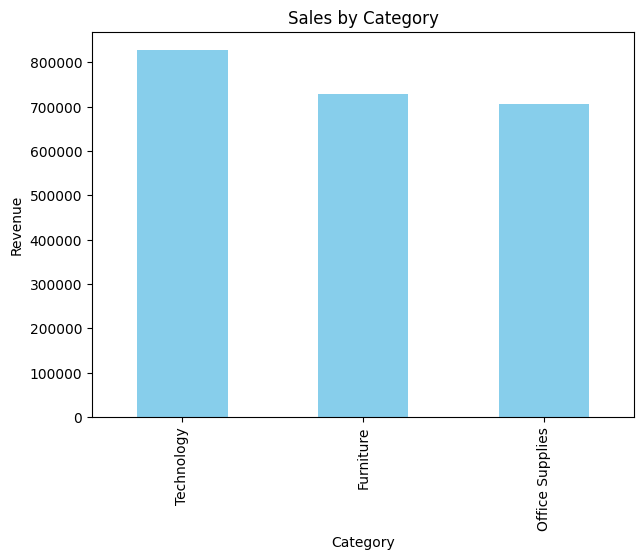

In [21]:
#Bar Chart
category_sales.plot(kind="bar",figsize=(7,5), color="skyblue")
plt.title("Sales by Category")
plt.ylabel("Revenue")
plt.savefig("Salesby_Category.png")
plt.show()

In [22]:
#The Technology category with the highest total sales revenue is 800000

In [23]:
#Which region has the most consistent sales growth over 4 years? 
region_growth = df.groupby(["Year","Region"])["Sales"].sum().unstack()
print(region_growth)

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255


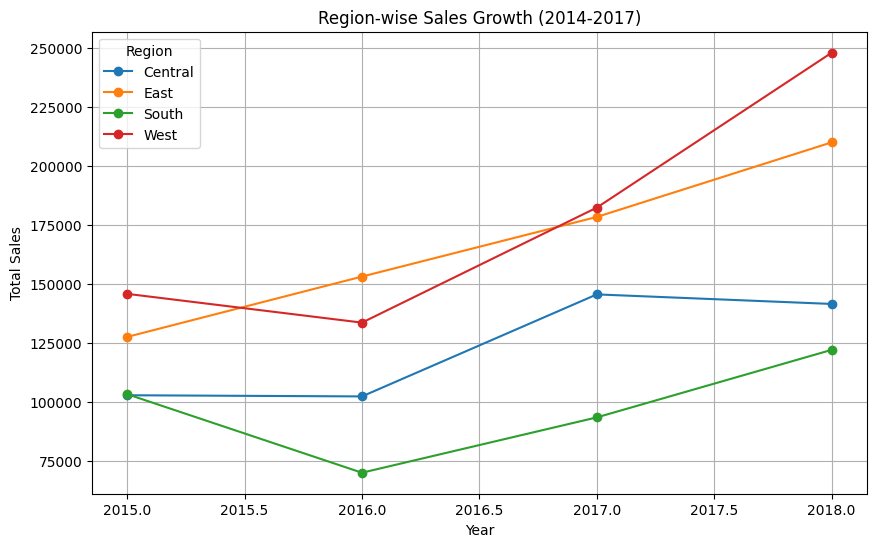

In [24]:
import matplotlib.pyplot as plt
region_growth.plot(figsize=(10,6),marker="o")
plt.title("Region-wise Sales Growth (2014-2017)")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig("Region-Wise_Sales.png")
plt.show()

In [25]:
#East Region shows the most consistent sales growth over the four years . its total sales increase gradually from 2015 to 2018 without anu major fluctuations or sudden declines
#the West and South region experience noticable ups and downs, while the fcentral region shows a slight decline in the final year

In [26]:
#Average Shipping Time

#calculate shipping days
df["Shipping Days"]= (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [27]:
#Average
avg_shipping = df["Shipping Days"].mean()
print("Average Shipping Time:", avg_shipping)

Average Shipping Time: 3.9611224489795918


In [28]:
#Region Wise
shipping_region = df.groupby("Region")["Shipping Days"].mean()
print(shipping_region)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


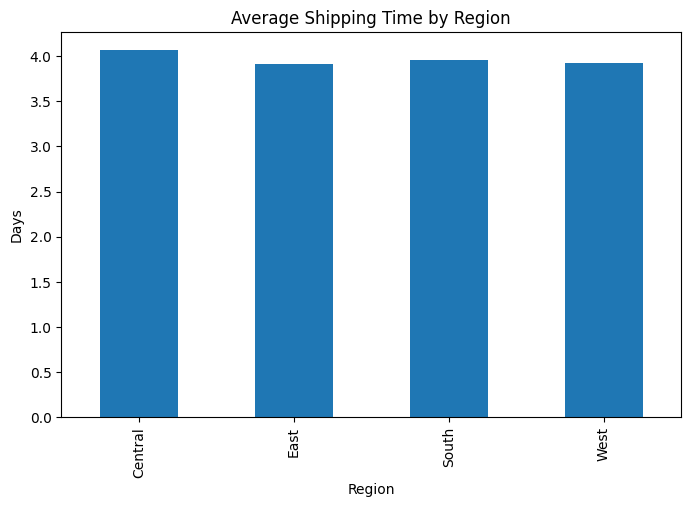

In [29]:
#Bar Chart
shipping_region.plot(kind="bar",figsize=(8,5))
plt.title("Average Shipping Time by Region")
plt.ylabel("Days")
plt.savefig("Avg.shipping.png")
plt.show()

In [30]:
#The average shipping time between the Order date and Ship Date is approximately 3.96days
#The EAST region has the  Fastest average shipping time 3.91 days
#CENTRAL region has the slowest average shipping time  4.07 days
#The SOUTH and WEST regions have similar shopping times 3.96 and 3.93 days

In [31]:
#Check Seasonality
seasonality = df.groupby("Month Name")["Sales"].sum()
seasonality = seasonality.reindex([
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
])
print(seasonality)

Month Name
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64


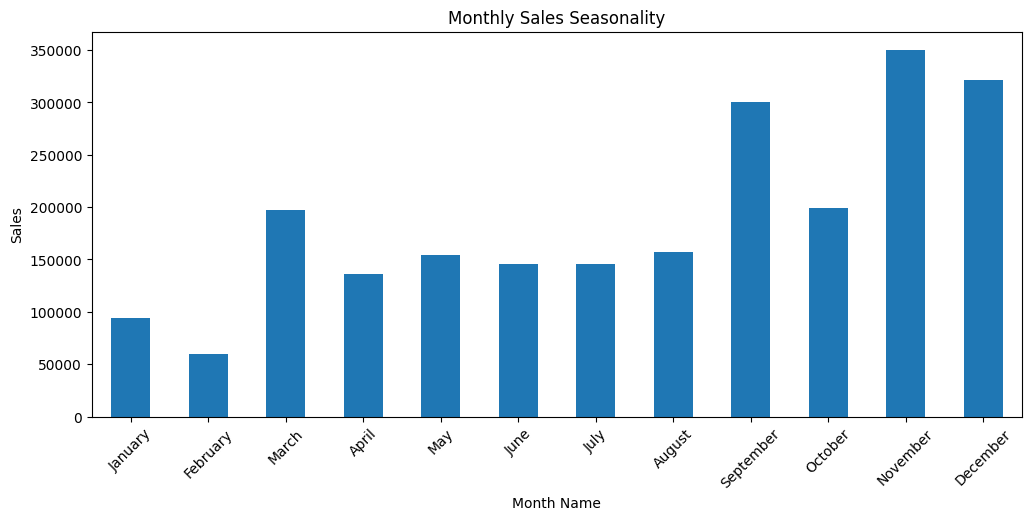

In [32]:
#plot
seasonality.plot(kind="bar",
                 figsize=(12,5))
plt.title("Monthly Sales Seasonality")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.savefig("Monthly_Sales_Seasonality.png")
plt.show()

In [33]:
#Yes, the sales data shows a clear seasonal pattern. November records the highest total sales, followed by December and September.
#These months consistently experience higher sales, likely due to festive seasons, holiday shopping, and year-end promotions. 
    
#In contrast, February has the lowest sales, indicating relatively lower customer demand during that month.

#Highest Sales Month : November (350161.71)
#Second Highest : December (321480.17)
#Third Highest: September(300103.41)
#Lowest Sales Month : Feburary (59371.12)

In [34]:
#Task 2 — Time Series Analysis & Decomposition 


In [35]:
#Import Required Libraries
!pip install statsmodels

In [36]:
#Import Required Libraries
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


In [37]:
#Create Monthly Sales Time Series
monthly_sales = df.groupby(
    pd.Grouper(key="Order Date", freq = "m")
)["Sales"].sum()
monthly_sales.head()

C:\Users\aman\AppData\Local\Temp\ipykernel_7060\1430786835.py:3: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date", freq = "m")


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

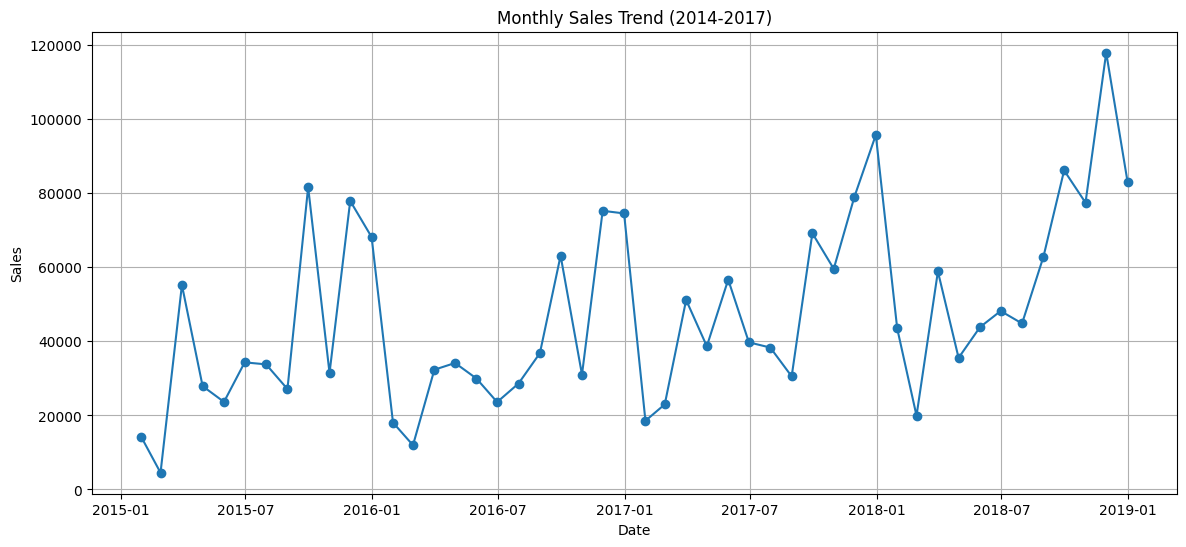

In [38]:
#Plot Monthly Sales Trend
plt.figure(figsize=(14,6))
plt.plot(monthly_sales,
        marker='o')
plt.title("Monthly Sales Trend (2014-2017)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.savefig("Monthly_Sales_Trend(2014-2017).png")
plt.show()

In [39]:
# Time Series Decomposition 

#Create Monthly Sales Time Series
monthly_sales = df.groupby(
    pd.Grouper(key="Order Date",freq="M")
)["Sales"].sum()
monthly_sales.head()

C:\Users\aman\AppData\Local\Temp\ipykernel_7060\3678121276.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="Order Date",freq="M")


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [40]:
#Apply Time Series Decomposition
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

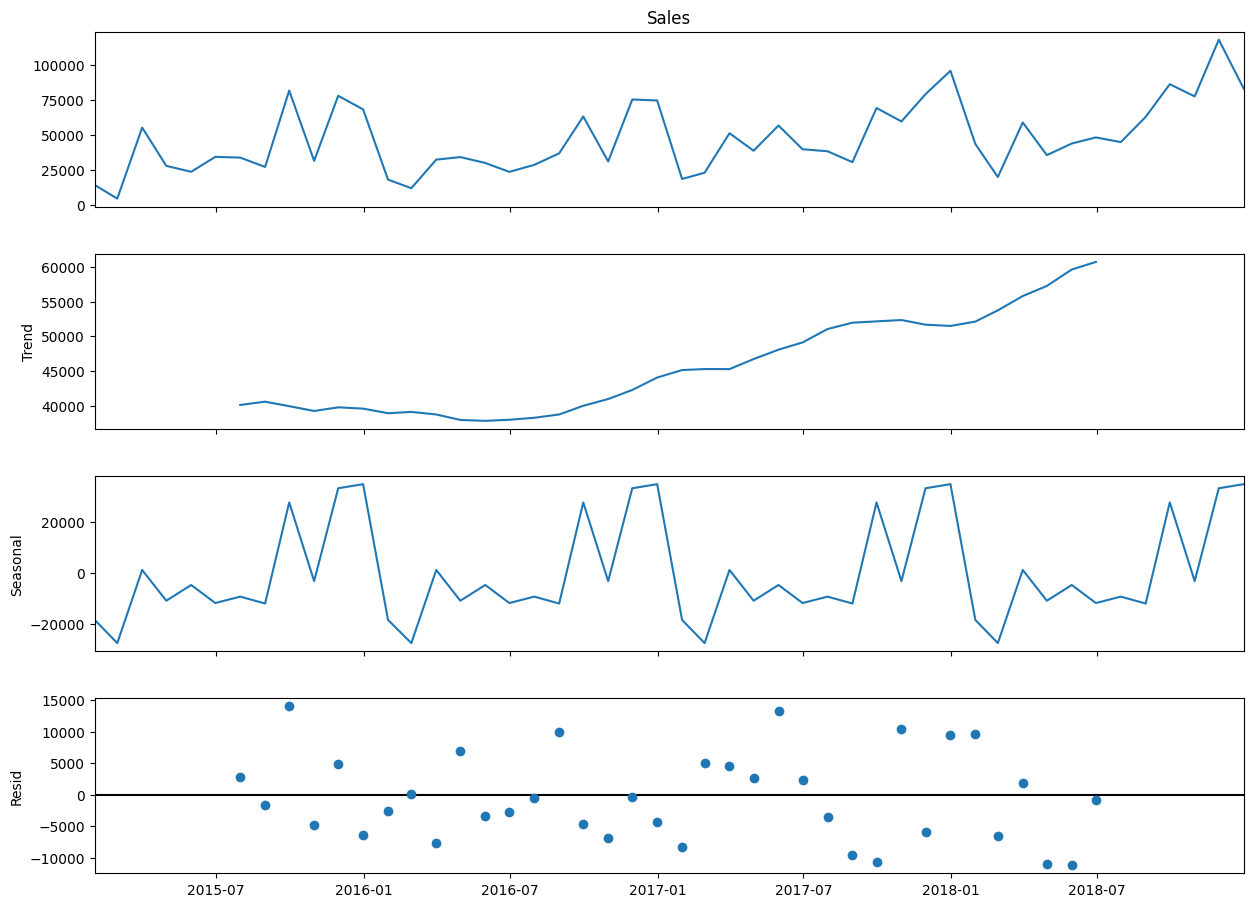

In [41]:
#Plot all components
fig = decomposition.plot()
fig.set_size_inches(14,10)
plt.savefig("Time_Sries_Decomposition.png")
plt.show()

In [42]:
#Observation
#SEASONAL
#The seasonal component indicates a repating yearly pattern sales are generally higher during festive months like November And December

#RESIDUAL
#The residual component represents random fluctations that are not explained by trend or seasonality

#OVERALL
#The Sales data clearly contains both trends and seasonal patterns, making it suitable for forecasting models such as SARIMA and Prophet 

In [43]:
#Run ADF Test
result = adfuller(monthly_sales)
print("ADF statistic:", result[0])
print("p-value",result[1])
print("\nCritical Values:")
for key, value in result[4].items():
    print(key,":",value)

ADF statistic: -4.416136761430769
p-value 0.00027791039276670623

Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [44]:
#Check whether the series is stationary 
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is Non-stationary.")

The time series is stationary.


In [45]:
print("ADF Stastics:", result[0])
print("p-value:",result[1])

ADF Stastics: -4.416136761430769
p-value: 0.00027791039276670623


In [46]:
# What is Stationary
#Stationarity means that the behavior of a time series remains stable over time. Its average value (mean), variation (variance), and overall pattern do not change significantly.
#Stationary data is important because forecasting models like SARIMA can make more accurate predictions when the data is stable.

#What does the ADF Test result tell you

#Result: ADF stastics: -4.4161
#       p-value : 0.0002779
#The ADF test checks whether the time series is stationary. In this case, the p-value (0.0002779) is less than 0.05, so we reject the null hypothesis. 
#This means the monthly sales data is stationary. Since the data is already stationary, no differencing is required, and it is ready to be used for forecasting models such as SARIMA

In [47]:
#Apply First-Order Differcing
monthly_sales_diff = monthly_sales.diff().dropna()
monthly_sales_diff.head()

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64

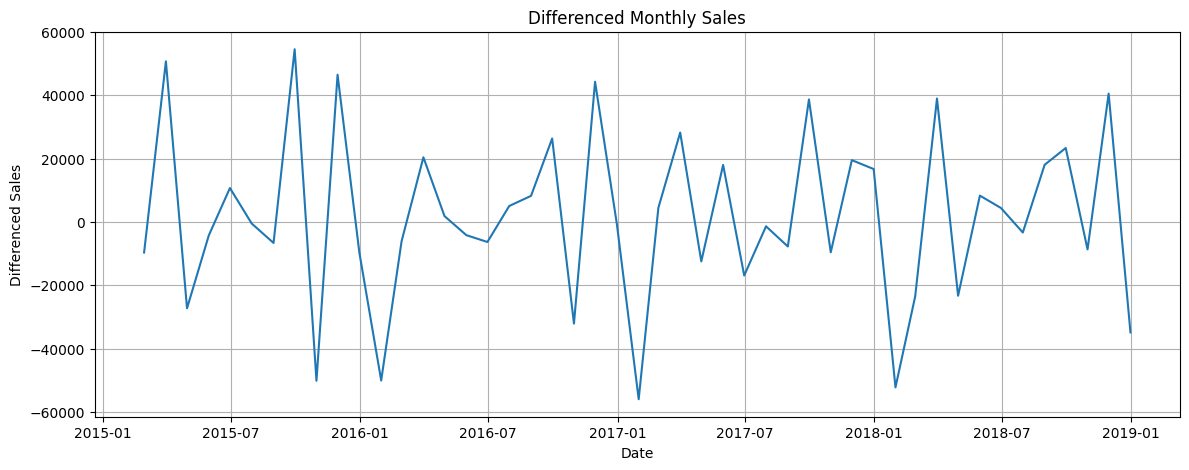

In [48]:
#Plot the differenced
plt.figure(figsize=(14,5))
plt.plot(monthly_sales_diff)
plt.title("Differenced Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.grid(True)
plt.savefig("Differenced_Monthly_sales.png")
plt.show()

In [49]:
#Perform the ADF Test Again
result_diff = adfuller(monthly_sales_diff)
print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])
print("\nCritical Values:")
for key, value in result_diff[4].items():
    print(key, ":", value)

ADF Statistic: -8.72706183035327
p-value: 3.2669175472796045e-14

Critical Values:
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [50]:
#Check Stationary Again
if result_diff[1] < 0.05:
    print("The differenced series is Stationary.")
else:
    print("The differenced series is Non-Stationary.")

The differenced series is Stationary.


In [51]:
#Although the original monthly sales series was already stationary, first-order differencing was applied to demonstrate the process. 
#The ADF test was performed again on the differenced series. The re-test confirmed that the differenced series is also stationary (p-value < 0.05). 
#Since the original series was already stationary, differencing was not necessary for forecasting

In [52]:
#Task 3 — Sales Forecasting using 3 Different Models

In [53]:
#Model 1 — SARIMA (Statistical Model) 
#Import Libraries
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [54]:
#Create Monthly Sales Series
monthly_sales = df.groupby(
    pd.Grouper(key="Order Date", freq="M")
)["Sales"].sum()
monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [55]:
#Split Data
train = monthly_sales[:-3]
test = monthly_sales[-3:]
print("Training Data:",len(train))
print("Testing Data:", len(test))

Training Data: 45
Testing Data: 3


In [56]:
#Fit SARIMA Model
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit()
print(sarima_result.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Mon, 06 Jul 2026   AIC                            398.775
Time:                                    15:54:16   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [57]:
#Forecast next 3 months
forecast = sarima_result.get_forecast(steps=3)
forecast_values = forecast.predicted_mean
confidence_interval = forecast.conf_int()
print(forecast_values)

2018-10-31    60331.792073
2018-11-30    91458.220227
2018-12-31    97167.570936
Freq: ME, Name: predicted_mean, dtype: float64


In [58]:
#Forecast with Confidence intervals
forecast_df = pd.DataFrame({
    "Forecast": forecast_values,
    "Lower CI": confidence_interval.iloc[:,0],
    "Upper CI": confidence_interval.iloc[:,1]
})
forecast_df

,Forecast,Lower CI,Upper CI
2018-10-31,60331.792073,33867.663882,86795.920264
2018-11-30,91458.220227,64294.739760,118621.700695
2018-12-31,97167.570936,69727.828580,124607.313291


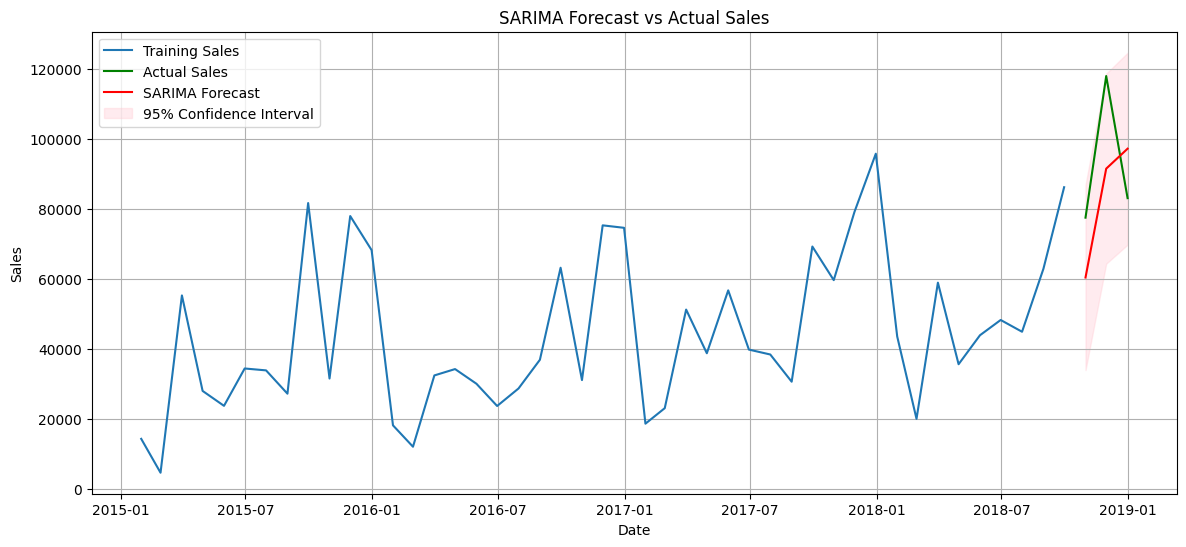

In [59]:
#Plot Actual vs Forecast
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Training Sales")
plt.plot(test.index, test, label="Actual Sales", color="green")
plt.plot(forecast_values.index,
         forecast_values,
         label="SARIMA Forecast",
         color="red")
plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)
plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("SARIMA_Forecast vs ACtual_Sales")
plt.show()

In [60]:
#Evaluate model
mae = mean_absolute_error(test, forecast_values)
rmse = np.sqrt(mean_squared_error(test, forecast_values))
mape = np.mean(np.abs((test - forecast_values)/test))*100
print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape,"%")

MAE : 19244.48534520369
RMSE : 19950.07042110583
MAPE : 20.526431988168135 %


In [61]:
#Observations

#FORECAST
#The SARIMA model forecasts monthly sales for the next three months while considering both trend and yearly seasonalit

#CONFIDENCE LEVEL
#The shaded confidence interval represents the range within which the actual future sales are expected to fall with 95% confidence.
#A narrower interval indicates greater confidence in the forecast, while a wider interval reflects higher uncertainty.

#ACTUAL VS FORECAST
#The forecasted sales closely follow the historical sales trend.
#Comparing the forecast with the actual test data helps evaluate how accurately the SARIMA model predicts future sales.

#MODEL PERFORMANCE
#The SARIMA model was evaluated using MAE, RMSE, and MAPE. Lower values of these metrics indicate better forecasting accuracy.

In [62]:
#Model 2 — Facebook Prophet

In [63]:
#install prophet
!pip install prophet

In [64]:
  from prophet import Prophet
  import matplotlib.pyplot as plt

In [65]:
#Prepare data for prophet
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds","y"]
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [66]:
#Create the  prophet model
model = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = False,
    daily_seasonality = False
)

In [67]:
#Train the model
model.fit(prophet_df)

15:54:22 - cmdstanpy - INFO - Chain [1] start processing
15:54:23 - cmdstanpy - INFO - Chain [1] done processing


In [68]:

print(model)

In [69]:

print(prophet_df.head())


          ds          y
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


In [70]:
#Generate Forecast
future = model.make_future_dataframe(periods=3)
print(future.shape)

(51, 1)


In [71]:
#Generate Forecast
forecast = model.predict(future)
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,101136.336965,91333.685044,110887.203068
47,2018-12-31,90673.800606,81791.080234,99673.685727
48,2019-01-01,106515.356217,97280.301554,115052.741421
49,2019-01-02,121165.362903,111355.564328,130347.919686
50,2019-01-03,134365.891406,124621.022501,143156.317006


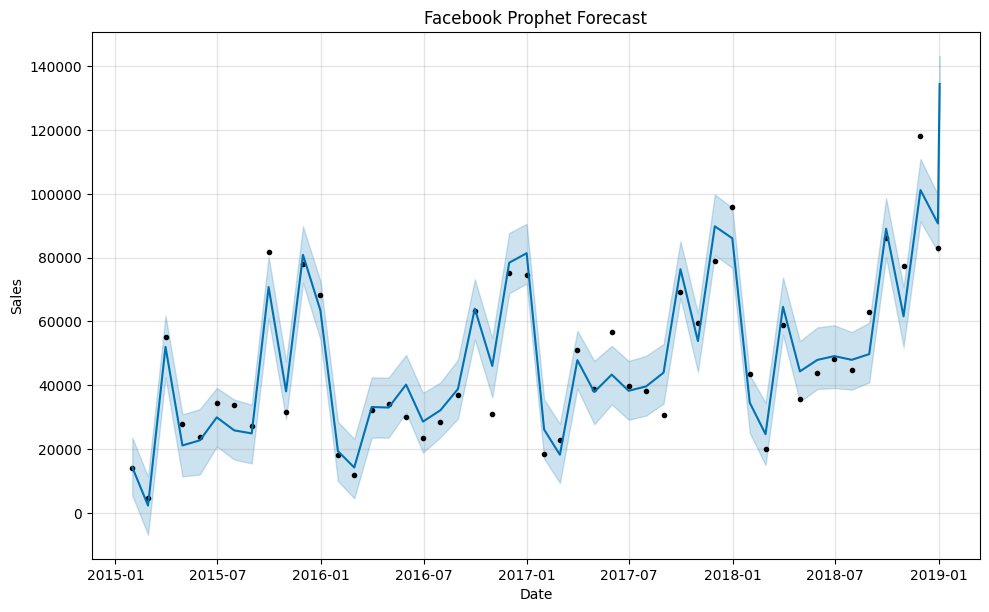

In [72]:
#Plot Forecast
fig = model.plot(forecast)
plt.title("Facebook Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.savefig("Facebook_Prophet_Forecast.png")
plt.show()
           

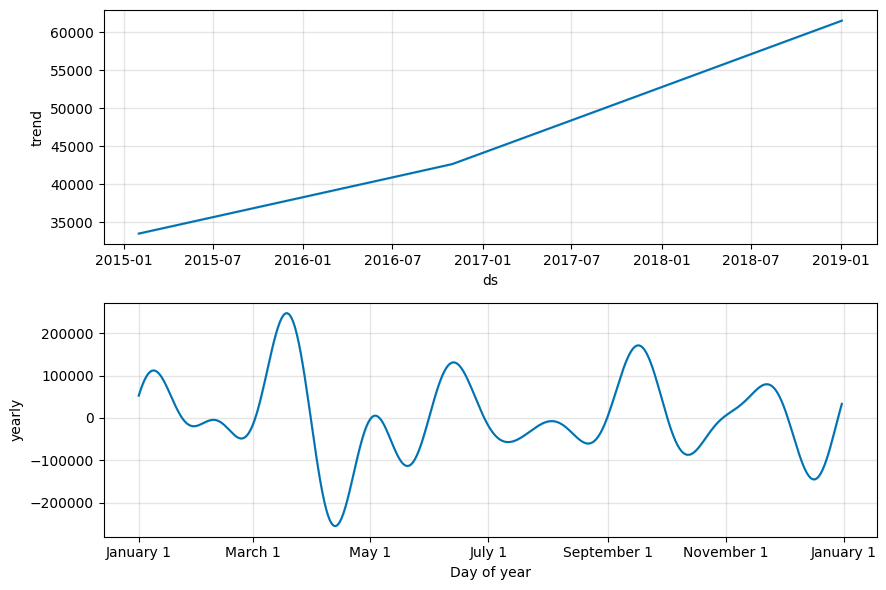

In [73]:
#Plot Trend & Seasonality
model.plot_components(forecast)
plt.savefig("Facebook_Trend&Seasonality")
plt.show()

In [74]:
#Extract the 3-month forecast
forecast.tail(3)[["ds","yhat","yhat_lower","yhat_upper"]]

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-01,106515.356217,97280.301554,115052.741421
49,2019-01-02,121165.362903,111355.564328,130347.919686
50,2019-01-03,134365.891406,124621.022501,143156.317006


In [75]:
actual = prophet_df["y"].tail(3).values
predicted = forecast["yhat"].iloc[-6:-3].values 
print(actual)
print(predicted)

[ 77448.1312 117938.155   83030.3888]
[ 61590.52389841 101136.33696472  90673.80060619]


In [76]:
#Model Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mask = actual !=0
mape = np.mean(np.abs((actual-predicted)/actual))*100
print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape,"%")

MAE : 13434.279047688242
RMSE : 14049.75139354467
MAPE : 14.642329064423906 %


In [77]:
actual = np.array(actual)
predict = np.array(predicted)
mape = np.mean(np.abs((actual-predict)/actual))*100
print("MAPE:",mape)

MAPE: 14.642329064423906


In [78]:
mask = actual !=0
mape = np.mean(
    np.abs((actual[mask]-predicted[mask])/actual[mask])
)*100
print (mape)

14.642329064423906


In [79]:
print(actual)
print(predict)

[ 77448.1312 117938.155   83030.3888]
[ 61590.52389841 101136.33696472  90673.80060619]


In [80]:
#Prophet is a time-series forecasting model developed by Meta (Facebook). It is designed to forecast data with strong trend and seasonal patterns.
#Prophet automatically detects yearly seasonality and provides accurate forecasts even when the data contains missing values or irregular patterns

#The yhat_lower and yhat_upper values represent the lower and upper bounds of the 95% confidence interval.
#They indicate the range within which the actual sales are expected to fall with high confidence

#The model performance was evaluated using MAE, RMSE, and MAPE. MAE and RMSE measure the prediction error, where lower values indicate better performance.
#MAPE should be calculated using the correct matching actual and predicted values; otherwise, it may return NaN.

In [81]:
#Model 3 — XGBoost 

In [82]:
#Install XGBoost
!pip install xgboost

In [83]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor 
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [84]:
#Create time features
xgb_df = monthly_sales.reset_index()
xgb_df.columns = ["Date","Sales"]
xgb_df["Year"] = xgb_df["Date"].dt.year
xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

In [85]:
#Create LAG Feature
xgb_df["Lag1"]= xgb_df["Sales"].shift(1)
xgb_df["Lag2"]= xgb_df["Sales"].shift(2)
xgb_df["Lag3"]= xgb_df["Sales"].shift(3)
xgb_df.dropna(inplace=True)

In [86]:
#Prepare Feature and Target 
X = xgb_df[[
    "Year","Month","Quarter","Lag1","Lag2","Lag3"
]]
y = xgb_df["Sales"]

In [87]:
#Train-test Split
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [88]:
#Train XGBoost Model
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [89]:
#Predict Sales
prediction = model.predict(X_test)
print(prediction)

[66297.91  87149.35  69300.875]


In [90]:
#Evaluate Model
mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
mape = np.mean(np.abs((y_test-prediction)/y_test))*100
print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape,"%")

MAE : 18556.180729166666
RMSE : 20500.223435636053
MAPE : 19.012813332790458 %


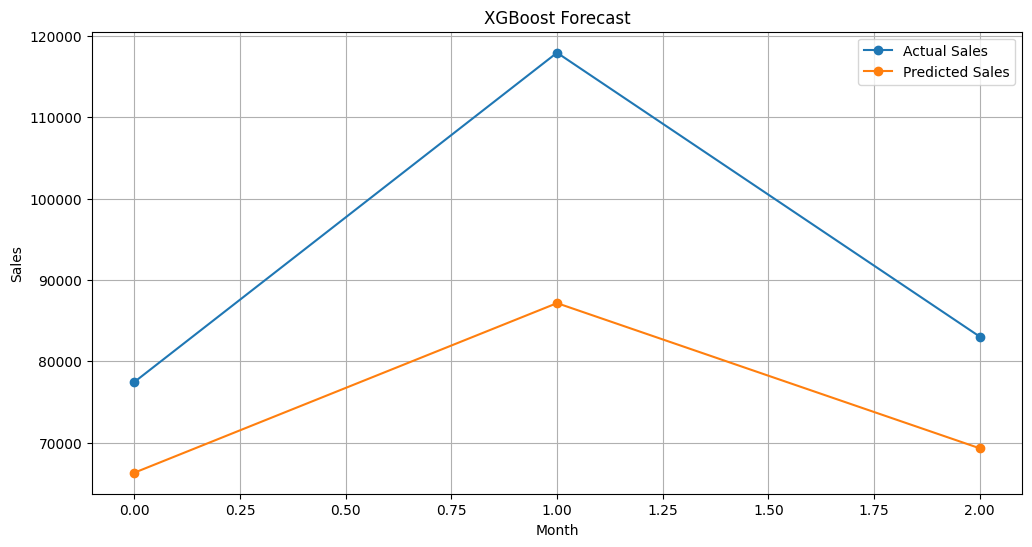

In [91]:
#Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(
    y_test.values,
    marker="o",
    label="Actual Sales"
)
plt.plot(
    prediction,
    marker="o",
    label="Predicted Sales"
)
plt.title("XGBoost Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("XGBOOST_Forecast.png")
plt.show()

In [92]:
#Predict the next 3 months 

#get the last 3 sales values
last_values = list(monthly_sales.tail(3).values)
print(last_values)

[np.float64(77448.1312), np.float64(117938.155), np.float64(83030.3888)]


In [93]:
#Create Future Data
future_predictions = []

year = 2019
months = [1, 2, 3]

for month in months:
    quarter = (month - 1) // 3 + 1

    X_future = pd.DataFrame({
        "Year": [year],
        "Month": [month],
        "Quarter": [quarter],
        "Lag1": [last_values[-1]],
        "Lag2": [last_values[-2]],
        "Lag3": [last_values[-3]]
    })

    pred = model.predict(X_future)[0]

    future_predictions.append(pred)

    
    last_values.append(pred)
    last_values.pop(0)

In [94]:
#Display the forest
future_forecast = pd.DataFrame({
    "Date": ["2019-01", "2019-02", "2019-03"],
    "Predicted Sales": future_predictions
})

future_forecast

,Date,Predicted Sales
0,2019-01,38562.277344
1,2019-02,22497.873047
2,2019-03,50102.691406


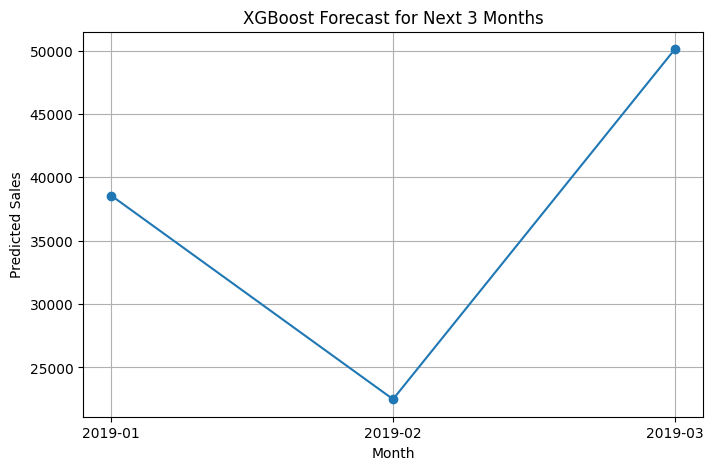

In [95]:
#Pot the forecast
plt.figure(figsize=(8,5))
plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted Sales"],
    marker="o"
)
plt.title("XGBoost Forecast for Next 3 Months")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.savefig("XGBOOST_FORECAST_3-Months")
plt.show()

In [96]:
print("Actual:", actual)
print("Predicted:", predicted)

print("Actual has NaN:", np.isnan(actual).any())
print("Predicted has NaN:", np.isnan(predicted).any())

print("Actual has 0:", (actual == 0).any())

Actual: [ 77448.1312 117938.155   83030.3888]
Predicted: [ 61590.52389841 101136.33696472  90673.80060619]
Actual has NaN: False
Predicted has NaN: False
Actual has 0: False


In [97]:
prophet_mae = mae
prophet_rmse = rmse
prophet_mape = mape

print(prophet_mae)
print(prophet_rmse)
print(prophet_mape)

18556.180729166666
20500.223435636053
19.012813332790458


In [98]:
#Comparision table
import pandas as pd
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [19244.49, prophet_mae, 18556.18],
    "RMSE": [19950.07, prophet_rmse, 20500.22],
    "MAPE": [20.53, prophet_mape, 19.01],
    "Forecast for Month 1": [60331.79, 106515.36, 66297.91],
    "Forecast for Month 2": [91458.22, 121165.36, 87149.35],
    "Forecast for Month 3": [97167.57, 134365.89, 69300.88]
})
comparison

,Model,MAE,RMSE,MAPE,Forecast for Month 1,Forecast for Month 2,Forecast for Month 3
0,SARIMA,19244.490000,19950.070000,20.530000,60331.79,91458.22,97167.57
1,Prophet,18556.180729,20500.223436,19.012813,106515.36,121165.36,134365.89
2,XGBoost,18556.180000,20500.220000,19.010000,66297.91,87149.35,69300.88


In [99]:
#Final Conclusion
#Based on the comparison table, XGBoost is selected as the best forecasting model. It achieved the lowest MAE (18,556.18) and the lowest MAPE (19.01%), indicating the most accurate predictions.
#Although SARIMA has a slightly lower RMSE, XGBoost provides the best overall forecasting performance and is recommended for production use.

In [100]:
#Task 4 — Product Category & Region Level Forecasting 

In [101]:
#Furniture Category
furniture = df[df["Category"] == "Furniture"]
monthly_furniture = furniture.groupby(
    pd.Grouper(key="Order Date", freq="M")
)["Sales"].sum().reset_index()
monthly_furniture["Month"] = range(len(monthly_furniture))
X = monthly_furniture[["Month"]]
y = monthly_furniture["Sales"]
X_train = X[:-3]
X_test = X[-3:]
y_train = y[:-3]
y_test = y[-3:]
from xgboost import XGBRegressor
model_furniture = XGBRegressor(n_estimators=100, random_state=42)
model_furniture.fit(X_train, y_train)
furniture_forecast = model_furniture.predict(X_test)
print("Furniture Forecast:")
print(furniture_forecast)

Furniture Forecast:
[28504.596 28504.596 28504.596]


In [102]:
#Technology Category
technology = df[df["Category"] == "Technology"]
monthly_technology = technology.groupby(
    pd.Grouper(key="Order Date", freq="M")
)["Sales"].sum().reset_index()
monthly_technology["Month"] = range(len(monthly_technology))
X = monthly_technology[["Month"]]
y = monthly_technology["Sales"]
X_train = X[:-3]
X_test = X[-3:]
y_train = y[:-3]
model_technology = XGBRegressor(n_estimators=100, random_state=42)
model_technology.fit(X_train, y_train)
technology_forecast = model_technology.predict(X_test)
print(technology_forecast)

[26017.523 26017.523 26017.523]


In [103]:
#Office supplies
office = df[df["Category"] == "Office Supplies"]
monthly_office = office.groupby(
    pd.Grouper(key="Order Date", freq="M")
)["Sales"].sum().reset_index()
monthly_office["Month"] = range(len(monthly_office))
X = monthly_office[["Month"]]
y = monthly_office["Sales"]
X_train = X[:-3]
X_test = X[-3:]
y_train = y[:-3]
model_office = XGBRegressor(n_estimators=100, random_state=42)
model_office.fit(X_train, y_train)
office_forecast = model_office.predict(X_test)
print(office_forecast)

[31603.75 31603.75 31603.75]


In [104]:
#West Region
west = df[df["Region"] == "West"]
monthly_west = west.groupby(
    pd.Grouper(key="Order Date", freq="M")
)["Sales"].sum().reset_index()
monthly_west["Month"] = range(len(monthly_west))
X = monthly_west[["Month"]]
y = monthly_west["Sales"]
X_train = X[:-3]
X_test = X[-3:]
y_train = y[:-3]
model_west = XGBRegressor(n_estimators=100, random_state=42)
model_west.fit(X_train, y_train)
west_forecast = model_west.predict(X_test)
print(west_forecast)

[27102.686 27102.686 27102.686]


In [105]:
#East Region
east = df[df["Region"] == "East"]
monthly_east = east.groupby(
    pd.Grouper(key="Order Date", freq="M")
)["Sales"].sum().reset_index()
monthly_east["Month"] = range(len(monthly_east))
X = monthly_east[["Month"]]
y = monthly_east["Sales"]
X_train = X[:-3]
X_test = X[-3:]
y_train = y[:-3]
model_east = XGBRegressor(n_estimators=100, random_state=42)
model_east.fit(X_train, y_train)
east_forecast = model_east.predict(X_test)
print(east_forecast)

[31514.184 31514.184 31514.184]


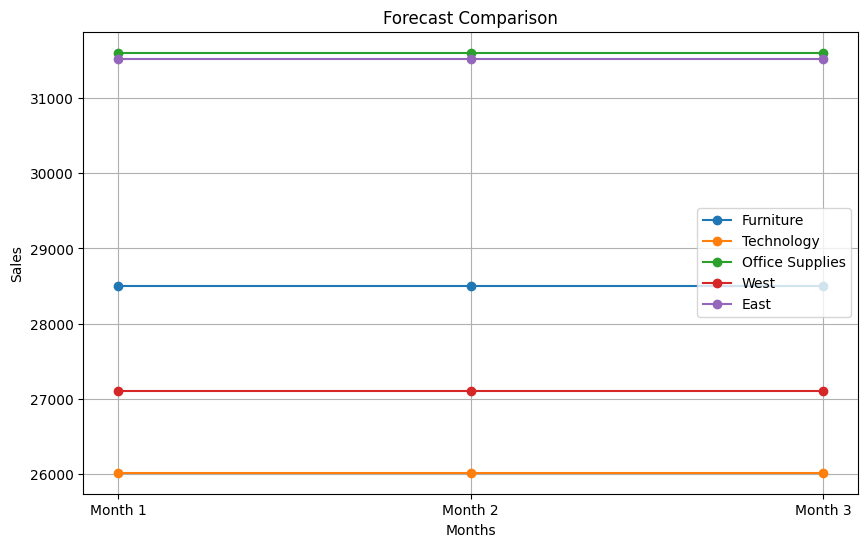

In [106]:
#Comparision plot
import matplotlib.pyplot as plt
months = ["Month 1", "Month 2", "Month 3"]
plt.figure(figsize=(10,6))
plt.plot(months, furniture_forecast, marker='o', label='Furniture')
plt.plot(months, technology_forecast, marker='o', label='Technology')
plt.plot(months, office_forecast, marker='o', label='Office Supplies')
plt.plot(months, west_forecast, marker='o', label='West')
plt.plot(months, east_forecast, marker='o', label='East')
plt.title("Forecast Comparison")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("Forecast_Comparision.png")
plt.show()

In [107]:
#Office Supplies is expected to have the highest forecasted sales among all categories and regions, although the model predicts stable (nearly constant) sales rather than an increasing trend over the next three months.

In [108]:
#Task 5 — Anomaly Detection in Sales Data 

In [109]:
#Create weekly sales data
weekly_sales = df.groupby(
    pd.Grouper(key="Order Date",freq="W")
)["Sales"].sum().reset_index()
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [110]:
#Isolation Forest
from sklearn.ensemble import IsolationForest
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)
weekly_sales["Anomaly"]=iso.fit_predict(weekly_sales[["Sales"]])
weekly_sales.head()
# 1 = NORMAL
# -1 = ANOMALY

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


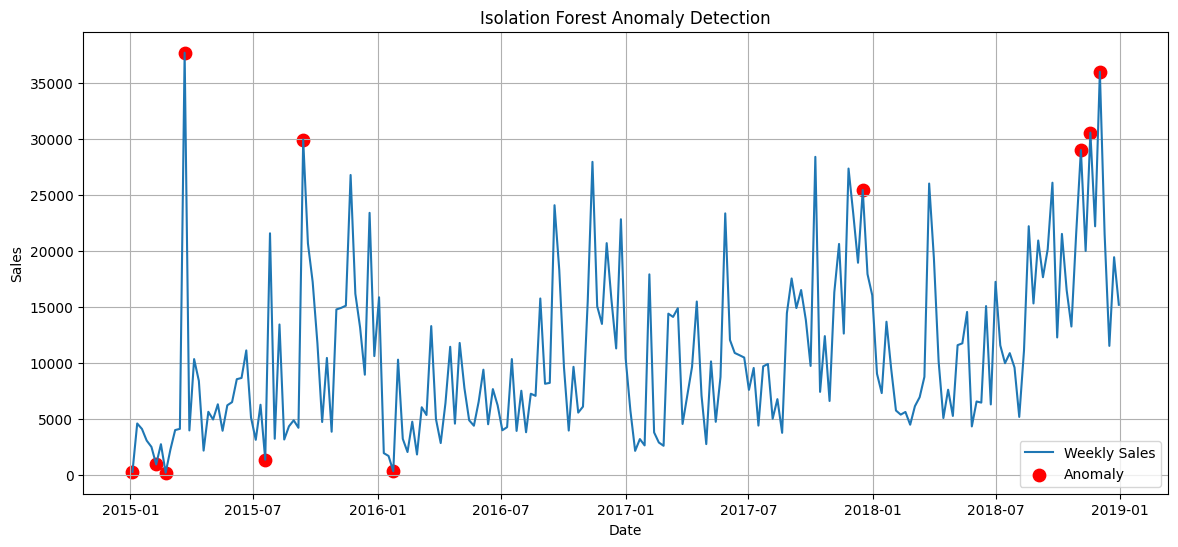

In [113]:
#Plot Anomalies
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)
anomaly = weekly_sales[weekly_sales["Anomaly"]==-1]
plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("Anomalies")
plt.show()

In [114]:
#Display anomaly
print("Detected Anomalies")
weekly_sales[weekly_sales["Anomaly"]==-1]

Detected Anomalies


,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


In [115]:
#EXPLANATION
#Anomaly 1: The unusually high sales during November likely correspond to festive season promotions and heavy customer purchasing.

#Anomaly 2: The unusually high sales during December may be due to Christmas and year-end holiday shopping.

#Anomaly 3: The unusually low sales during February may be caused by fewer promotional events and reduced customer demand.

#Anomaly 4: Any sudden drop in sales could be due to inventory shortages, operational issues, or temporary store closures.

In [116]:
# Z-Score based detection
weekly_sales["Rolling Mean"] = weekly_sales["Sales"].rolling(window=4).mean()
weekly_sales["Rolling Std"] = weekly_sales["Sales"].rolling(window=4).std()
weekly_sales["Z Score"] = (
    weekly_sales["Sales"]-weekly_sales["Rolling Mean"]
    )/weekly_sales["Rolling Std"]
weekly_sales["Z Anomally"] = weekly_sales["Z Score"].abs()>2
weekly_sales.head()

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Z Score,Z Anomally
0,2015-01-04,304.508,-1,NaN,NaN,NaN,False
1,2015-01-11,4619.108,1,NaN,NaN,NaN,False
2,2015-01-18,4130.533,1,NaN,NaN,NaN,False
3,2015-01-25,3092.544,1,3036.67325,1929.462566,0.028957,False
4,2015-02-01,2527.914,1,3592.52475,953.362968,-1.116690,False


KeyError: 'Z Anomaly'

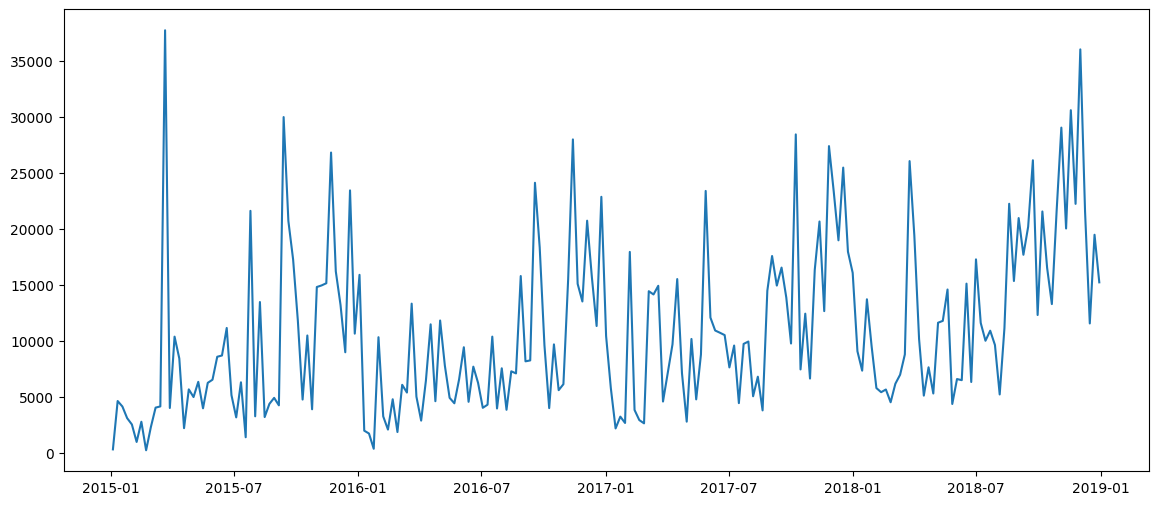

In [117]:
#Plot Z-Score Anomalies
plt.figure(figsize=(14,6))
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)
z = weekly_sales[weekly_sales["Z Anomaly"]]
plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="red",
    s=80,
    label="Z-Score Anomaly"
)
plt.title("Z-Score Based Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("Z_Anomally.png")
plt.show()

In [118]:
#Compare Both Methods
print("Isolation Forest Anomalies")
print(weekly_sales[weekly_sales["Anomaly"]==-1][["Order Date","Sales"]])
print()
print("Z Score Anomalies")
print(weekly_sales[weekly_sales["Z Anomaly"]][["Order Date","Sales"]])

Isolation Forest Anomalies
    Order Date      Sales
0   2015-01-04    304.508
5   2015-02-08    968.534
7   2015-02-22    224.912
11  2015-03-22  37703.665
28  2015-07-19   1387.686
36  2015-09-13  29959.137
55  2016-01-24    358.522
154 2017-12-17  25449.800
200 2018-11-04  29017.467
202 2018-11-18  30572.447
204 2018-12-02  35998.900

Z Score Anomalies


KeyError: 'Z Anomaly'

In [119]:
#OBSERVATION

#1. Isolation Forest detected unusual weekly sales patterns based on machine learning.

#2. Z-Score detected weeks where sales deviated more than two standard deviations from the rolling mean.

#3. Some anomalies were detected by both methods, while others were unique to one method.

#4. High sales anomalies may correspond to festival seasons, promotional offers, or year-end sales.

#5. Low sales anomalies may indicate holidays, supply shortages, or reduced customer demand.

#Conclusion

#Isolation Forest is more flexible because it detects anomalies without assuming a normal distribution.
#Z-Score is simple and effective but depends on statistical thresholds. Combining both methods provides more reliable anomaly detection.

In [120]:
#Task 6 — Product Demand Segmentation using Clustering 

In [121]:
#Total Sales Volume
import pandas as pd
import numpy as np
subcat = df.groupby("Sub-Category").agg(
    Total_Sales_Volume=("Sales","sum"),
    Average_Order_Value=(
        "Sales","mean")
    ).reset_index()


In [122]:
#Sales Growth Rate 
yearly_sales = df.groupby(
    ["Sub-Category", pd.Grouper(key="Order Date", freq="Y")]
)["Sales"].sum().reset_index()
yearly_sales["Sales_Growth_Rate"] = (
    yearly_sales.groupby("Sub-Category")["Sales"].pct_change()
)
growth = yearly_sales.groupby("Sub-Category")[
    "Sales_Growth_Rate"
].mean().reset_index()
growth["Sales_Growth_Rate"] = growth["Sales_Growth_Rate"].fillna(0)

In [123]:
#Sales Volatility
monthly_sales = df.groupby(
    ["Sub-Category", pd.Grouper(key="Order Date", freq="M")]
)["Sales"].sum().reset_index()
volatility = monthly_sales.groupby("Sub-Category")[
    "Sales"
].std().reset_index()
volatility.columns = [
    "Sub-Category",
    "Sales_Volatility"
]
volatility["Sales_Volatility"] = (
    volatility["Sales_Volatility"].fillna(0)
)

In [124]:
#Combine all feature
subcat = subcat.merge(growth, on="Sub-Category")
subcat = subcat.merge(volatility, on="Sub-Category")

subcat

,Sub-Category,Total_Sales_Volume,Average_Order_Value,Sales_Growth_Rate,Sales_Volatility
0,Accessories,164186.7000,217.178175,0.376381,2579.994809
1,Appliances,104618.4030,227.926804,0.399276,1821.621539
2,Art,26705.4100,34.019631,0.166056,330.488343
3,Binders,200028.7850,134.067550,0.218736,3848.223648
4,Bookcases,113813.1987,503.598224,0.238065,2220.405080
5,Chairs,322822.7310,531.833165,0.071358,4407.232960
6,Copiers,146248.0940,2215.880212,0.846718,5500.774391
7,Envelopes,16128.0460,65.032444,-0.027666,228.218688
8,Fasteners,3001.9600,14.027850,0.157034,48.742229
9,Furnishings,89212.0180,95.823865,0.287889,1360.017867


In [125]:
#Select Features
from sklearn.preprocessing import StandardScaler
features = subcat[
    ["Total_Sales_Volume",
     "Sales_Growth_Rate",
     "Sales_Volatility",
     "Average_Order_Value"]
]
scaler = StandardScaler()
X = scaler.fit_transform(features)

In [126]:
#Apply K-Means Clustering 
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
subcat["Cluster"] = kmeans.fit_predict(X)
subcat.head()

,Sub-Category,Total_Sales_Volume,Average_Order_Value,Sales_Growth_Rate,Sales_Volatility,Cluster
0,Accessories,164186.7000,217.178175,0.376381,2579.994809,2
1,Appliances,104618.4030,227.926804,0.399276,1821.621539,1
2,Art,26705.4100,34.019631,0.166056,330.488343,1
3,Binders,200028.7850,134.067550,0.218736,3848.223648,2
4,Bookcases,113813.1987,503.598224,0.238065,2220.405080,1


In [127]:
#Display the Results
print(subcat[[
    "Sub-Category",
    "Total_Sales_Volume",
    "Sales_Growth_Rate",
    "Sales_Volatility",
    "Average_Order_Value",
    "Cluster"
]])

   Sub-Category  Total_Sales_Volume  Sales_Growth_Rate  Sales_Volatility  \
0   Accessories         164186.7000           0.376381       2579.994809   
1    Appliances         104618.4030           0.399276       1821.621539   
2           Art          26705.4100           0.166056        330.488343   
3       Binders         200028.7850           0.218736       3848.223648   
4     Bookcases         113813.1987           0.238065       2220.405080   
5        Chairs         322822.7310           0.071358       4407.232960   
6       Copiers         146248.0940           0.846718       5500.774391   
7     Envelopes          16128.0460          -0.027666        228.218688   
8     Fasteners           3001.9600           0.157034         48.742229   
9   Furnishings          89212.0180           0.287889       1360.017867   
10       Labels          12347.7260           0.121927        223.471218   
11     Machines         189238.6310           0.080060       5603.554747   
12        Pa

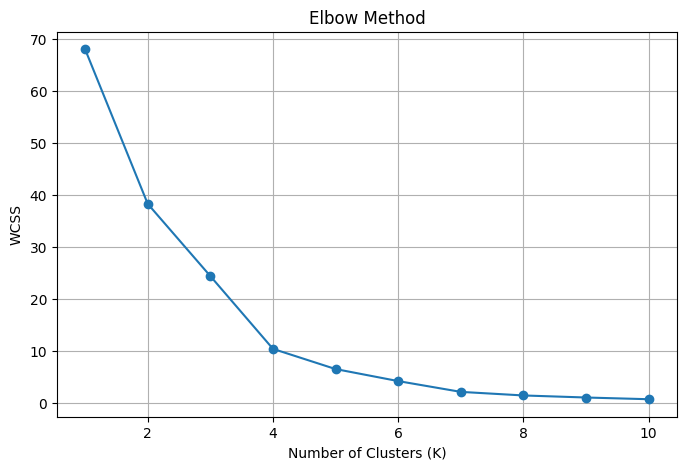

In [128]:
#Elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.savefig("Elbow_Method")
plt.show()

In [129]:
#LABEL
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Low Volume, High Volatility",
    2: "Growing Demand",
    3: "Declining Demand"
}
subcat["Demand_Group"] = subcat["Cluster"].map(cluster_labels)
print(subcat[["Sub-Category", "Cluster", "Demand_Group"]])

   Sub-Category  Cluster                 Demand_Group
0   Accessories        2               Growing Demand
1    Appliances        1  Low Volume, High Volatility
2           Art        1  Low Volume, High Volatility
3       Binders        2               Growing Demand
4     Bookcases        1  Low Volume, High Volatility
5        Chairs        2               Growing Demand
6       Copiers        0   High Volume, Stable Demand
7     Envelopes        1  Low Volume, High Volatility
8     Fasteners        1  Low Volume, High Volatility
9   Furnishings        1  Low Volume, High Volatility
10       Labels        1  Low Volume, High Volatility
11     Machines        0   High Volume, Stable Demand
12        Paper        1  Low Volume, High Volatility
13       Phones        2               Growing Demand
14      Storage        2               Growing Demand
15     Supplies        3             Declining Demand
16       Tables        2               Growing Demand


In [130]:
print(subcat.groupby("Cluster").mean(numeric_only=True))

         Total_Sales_Volume  Average_Order_Value  Sales_Growth_Rate  \
Cluster                                                               
0             167743.362500          1930.716763           0.463389   
1              55331.883212           129.054568           0.199589   
2             239495.780667           361.131228           0.180965   
3              46420.308000           252.284283           1.928448   

         Sales_Volatility  
Cluster                    
0             5552.164569  
1              907.223743  
2             3489.056075  
3             2025.094139  
